# 국민여행조사 지역코드 연도 비교

## 분석 목적과 범위
- 2023·2024·2025 SAV 메타데이터의 방문지역 값 라벨을 비교한다.
- 분석 단위는 국민여행조사 방문지역 코드 1행이다.
- 식별키는 시도_코드 + 시군구_코드 복합키다.
- 연속 연도의 신규·소멸 코드, 명칭 변경, 코드 변경을 확인한다.

이 코드는 범용 행정구역 코드가 아니라 연도별 국민여행조사 SAV의 코드북 메타데이터를 비교한다.

In [1]:
from pathlib import Path
import sys

current = Path.cwd().resolve()
project_root = next(
    (x for x in (current, *current.parents)
     if (x / "src").is_dir() and (x / "data").is_dir()),
    None,
)
if project_root is None:
    raise FileNotFoundError("프로젝트 루트를 찾을 수 없습니다.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import pandas as pd
import pyreadstat
from IPython.display import display

from src.path import (
    NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR,
    create_output_directories,
)
from src.visualization import COLORS, apply_plot_style

pd.set_option("display.max_rows", 100)
YEARS = (2023, 2024, 2025)
INPUT_PATHS = {
    int(path.name[:4]): path
    for path in NATIONAL_TRAVEL_SURVEY_RAW_DATA_DIR.glob("y*/*")
    if path.suffix.lower() == ".sav"
}
assert set(INPUT_PATHS) == set(YEARS)
COLUMNS = ["시도_코드", "시도명", "시군구_코드", "시군구명"]
KEY = ["시도_코드", "시군구_코드"]
NAMES = ["시도명", "시군구명"]
FIGURES_DIR, _ = create_output_directories(
    "260719_국민여행조사_지역코드_연도비교.ipynb"
)
FIGURE_PATH = FIGURES_DIR / "region_code_changes_2023_2025.png"
INPUT_PATHS

{2023: WindowsPath('C:/Users/ilove/Desktop/tourism_poster/data/raw/national_travel_survey/2023년_국민여행조사_국내여행.SAV'),
 2024: WindowsPath('C:/Users/ilove/Desktop/tourism_poster/data/raw/national_travel_survey/2024년_국민여행조사_국내여행.sav'),
 2025: WindowsPath('C:/Users/ilove/Desktop/tourism_poster/data/raw/national_travel_survey/2025년_국민여행조사_국내여행.SAV')}

## 데이터 로드
SAV를 메타데이터 전용으로 읽고 방문지역 코드를 5자리 문자열로 변환한다.
시군구 코드가 `000`인 시도 수준 라벨은 전용 지역코드의 분석 단위가 아니므로 제외한다.

In [2]:
def load_region_codes(path: Path, year: int) -> pd.DataFrame:
    """SAV 메타데이터에서 연도별 방문지역 코드를 읽는다.

    Args:
        path: 국민여행조사 SAV 경로.
        year: 조사 연도.

    Returns:
        연도 열이 추가된 지역코드 데이터프레임.
    """
    _, metadata = pyreadstat.read_sav(path, metadataonly=True)
    labels = metadata.variable_value_labels["D_TRA1_1_SPOT"]
    rows = []
    for value, label in labels.items():
        spot_code = f"{int(value):05d}"
        if spot_code.endswith("000"):
            continue
        sido_name, sigungu_name = label.split(" ", maxsplit=1)
        rows.append({
            "시도_코드": spot_code[:2],
            "시도명": sido_name,
            "시군구_코드": spot_code[2:],
            "시군구명": sigungu_name,
        })
    data = pd.DataFrame(rows, columns=COLUMNS, dtype="string")
    data["연도"] = year
    return data


region_codes = {
    year: load_region_codes(path, year)
    for year, path in INPUT_PATHS.items()
}
pd.DataFrame({
    "연도": YEARS,
    "파일": [INPUT_PATHS[y].name for y in YEARS],
    "행수": [len(region_codes[y]) for y in YEARS],
})

,연도,파일,행수
0,2023,2023년_국민여행조사_국내여행.SAV,229
1,2024,2024년_국민여행조사_국내여행.sav,229
2,2025,2025년_국민여행조사_국내여행.SAV,229


## 데이터 품질과 분석 단위 확인
열, 결측, 전체 행 중복, 복합키 중복과 코드 자릿수를 점검한다.

In [3]:
quality_rows = []
for year, data in region_codes.items():
    missing = int(data[COLUMNS].isna().sum().sum())
    row_duplicates = int(data.duplicated(COLUMNS).sum())
    key_duplicates = int(data.duplicated(KEY).sum())
    sido_valid = data["시도_코드"].str.fullmatch(r"\d{2}").all()
    sigungu_valid = data["시군구_코드"].str.fullmatch(r"\d{3}").all()
    quality_rows.append({
        "연도": year,
        "행수": len(data),
        "열수": len(COLUMNS),
        "결측수": missing,
        "전체행_중복수": row_duplicates,
        "복합키_중복수": key_duplicates,
        "시도코드_2자리": bool(sido_valid),
        "시군구코드_3자리": bool(sigungu_valid),
    })
    assert list(data.columns[:4]) == COLUMNS
    assert missing == row_duplicates == key_duplicates == 0
    assert sido_valid and sigungu_valid

quality_summary = pd.DataFrame(quality_rows)
quality_summary

,연도,행수,열수,결측수,전체행_중복수,복합키_중복수,시도코드_2자리,시군구코드_3자리
0,2023,229,4,0,0,0,True,True
1,2024,229,4,0,0,0,True,True
2,2025,229,4,0,0,0,True,True


## 전처리 및 비교 기준
- 신규·소멸: 복합키가 다음 연도에 새로 등장하거나 사라진 경우
- 명칭 변경: 복합키는 같지만 시도명 또는 시군구명이 달라진 경우
- 코드 변경: 시도명과 시군구명이 모두 같지만 복합키가 달라진 경우

명칭과 코드가 동시에 바뀐 곳은 공식 이력 없이는 동일 지역으로 단정하지 않는다.

In [4]:
for data in region_codes.values():
    data["spot_code"] = data["시도_코드"] + data["시군구_코드"]
    assert data["spot_code"].str.fullmatch(r"\d{5}").all()
    assert data["spot_code"].is_unique

region_codes[2023].head()

,시도_코드,시도명,시군구_코드,시군구명,연도,spot_code
0,11,서울특별시,010,종로구,2023,11010
1,11,서울특별시,020,중구,2023,11020
2,11,서울특별시,030,용산구,2023,11030
3,11,서울특별시,040,성동구,2023,11040
4,11,서울특별시,050,광진구,2023,11050


## 연속 연도 비교

In [5]:
def compare_region_codes(
    old_data: pd.DataFrame,
    new_data: pd.DataFrame,
) -> dict[str, pd.DataFrame]:
    """두 연도의 지역코드 변경을 유형별로 비교한다.

    Args:
        old_data: 이전 연도 지역코드.
        new_data: 다음 연도 지역코드.

    Returns:
        변경 유형별 상세 데이터프레임.
    """
    by_key = old_data.merge(
        new_data,
        on=KEY,
        how="outer",
        suffixes=("_이전", "_다음"),
        indicator=True,
        validate="one_to_one",
    )
    added = by_key.loc[
        by_key["_merge"].eq("right_only"),
        KEY + ["시도명_다음", "시군구명_다음", "spot_code_다음"],
    ].reset_index(drop=True)
    removed = by_key.loc[
        by_key["_merge"].eq("left_only"),
        KEY + ["시도명_이전", "시군구명_이전", "spot_code_이전"],
    ].reset_index(drop=True)
    matched = by_key["_merge"].eq("both")
    renamed = by_key.loc[
        matched & (
            by_key["시도명_이전"].ne(by_key["시도명_다음"])
            | by_key["시군구명_이전"].ne(by_key["시군구명_다음"])
        ),
        KEY + ["시도명_이전", "시도명_다음", "시군구명_이전", "시군구명_다음"],
    ].reset_index(drop=True)

    by_name = old_data.merge(
        new_data,
        on=NAMES,
        how="inner",
        suffixes=("_이전", "_다음"),
        validate="one_to_one",
    )
    recoded = by_name.loc[
        by_name["시도_코드_이전"].ne(by_name["시도_코드_다음"])
        | by_name["시군구_코드_이전"].ne(by_name["시군구_코드_다음"]),
        NAMES + [
            "시도_코드_이전", "시도_코드_다음",
            "시군구_코드_이전", "시군구_코드_다음",
        ],
    ].reset_index(drop=True)
    return {
        "신규 코드": added,
        "소멸 코드": removed,
        "명칭 변경": renamed,
        "코드 변경": recoded,
    }


PERIODS = ((2023, 2024), (2024, 2025))
results = {
    f"{old}→{new}": compare_region_codes(region_codes[old], region_codes[new])
    for old, new in PERIODS
}
change_summary = pd.DataFrame([
    {"비교기간": period, **{kind: len(table) for kind, table in result.items()}}
    for period, result in results.items()
])
change_summary

,비교기간,신규 코드,소멸 코드,명칭 변경,코드 변경
0,2023→2024,0,0,0,0
1,2024→2025,0,0,0,0


In [6]:
has_changes = False
for period, result in results.items():
    for kind, detail in result.items():
        if detail.empty:
            continue
        has_changes = True
        print(f"[{period}] {kind}: {len(detail)}건")
        display(detail)

if not has_changes:
    print("2023→2024와 2024→2025 모두 지역 코드 및 지역명 변경이 없습니다.")

2023→2024와 2024→2025 모두 지역 코드 및 지역명 변경이 없습니다.


## 시각화
연속 연도 사이에 변경 유형별 지역이 몇 곳인지 막대와 직접 레이블로 확인한다.

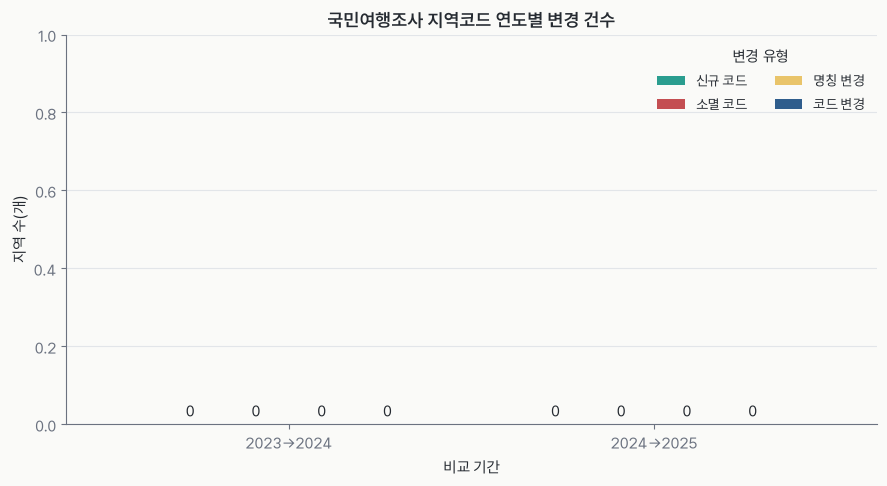

WindowsPath('C:/Users/ilove/Desktop/tourism_poster/outputs/260719_국민여행조사_지역코드_연도비교/figures/region_code_changes_2023_2025.png')

In [7]:
apply_plot_style()
plot_data = change_summary.set_index("비교기간")
colors = [
    COLORS["secondary"], COLORS["negative"],
    COLORS["highlight"], COLORS["primary"],
]
figure, axis = plt.subplots(figsize=(9, 5))
plot_data.plot(kind="bar", ax=axis, color=colors, width=0.72)
axis.set_title("국민여행조사 지역코드 연도별 변경 건수")
axis.set_xlabel("비교 기간")
axis.set_ylabel("지역 수(개)")
axis.set_ylim(0, max(1, float(plot_data.to_numpy().max()) * 1.2))
axis.tick_params(axis="x", rotation=0)
axis.grid(axis="y")
axis.legend(title="변경 유형", frameon=False, ncol=2)
for container in axis.containers:
    axis.bar_label(container, fmt="%.0f", padding=3)
figure.tight_layout()
figure.savefig(FIGURE_PATH, dpi=900, bbox_inches="tight")
plt.show()
FIGURE_PATH

## 핵심 결과와 한계
- 실행 결과는 세 SAV 메타데이터의 방문지역 값 라벨을 직접 비교한 것이다.
- 복합키와 명칭이 동시에 바뀌면 공식 변경 이력 없이 동일 지역으로 연결하지 않았다.
- 국민여행조사 전용 보조 코드이므로 실제 행정구역 개편 시점과 다를 수 있다.
- 여행자료 결합 시 연도별 코드표, many_to_one 관계와 미매칭 코드를 검증해야 한다.